In [7]:
!pip install ultralytics timm

In [8]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!unzip -q "/content/drive/MyDrive/vinbig/vinbig_images.zip" -d /content/
!unzip -q "/content/drive/MyDrive/vinbig/vinbig_labels.zip" -d /content/

In [10]:
import os

os.listdir("/content")

['.config', 'drive', 'kaggle', 'yolov8n.pt', 'runs', 'sample_data']

In [11]:
!apt-get install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (55.6 kB/s)
Selecting previously unselected package tree.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [12]:
!tree -L 3 /content

/content
├── drive
│   └── MyDrive
│       ├── 1M1B PROJECT.pdf
│       ├── 3144301 - UNIT - 1_copy.pdf
│       ├── 3164301 - LAB MANUAL.gdoc
│       ├── ASF's OMAD guide.docx
│       ├── Certificate (5)_compressed (1).pdf
│       ├── Certificate (5)_compressed.pdf
│       ├── Classroom
│       ├── Colab Notebooks
│       ├── Completion Certificate _ 1M1B.pdf
│       ├── Completion Certificate _ SkillsBuild.pdf
│       ├── Final Project ppt template (1).pptx
│       ├── Final Project ppt template.pptx
│       ├── Flipkart PYQ - Arsh Goyal.gdoc
│       ├── Frontend Developer Task.docx
│       ├── INDEX WAD.pdf
│       ├── Kalpana – Coding Jr Internship Assignment
│       ├── kp final resume.pdf
│       ├── Notes Sem 3 
│       ├── PPT  CYBER GYAN VIRTUAL INTERNSHIP.pptx
│       ├── PROJECT REPORT CYBER GYAN VIRTUAL INTERNSHIP.docx
│       ├── Screenshot 2026-01-07 150233.png
│       ├── Screenshot 2026-01-07 150406.png
│       ├── Screenshot 2026-01-07 150619.png
│       ├── Sem 6 paper

In [13]:
!find /content -type d -name "train"

/content/kaggle/working/vinbig_yolo/labels/train
/content/kaggle/working/vinbig_yolo/images/train
/content/runs/detect/train


In [14]:
img_dir = "/content/kaggle/working/vinbig_yolo/images/train"
label_dir = "/content/kaggle/working/vinbig_yolo/labels/train"

In [15]:
img_dir = "/content/kaggle/working/vinbig_yolo/images/train"
label_dir = "/content/kaggle/working/vinbig_yolo/labels/train"

import os
print("Images:", len(os.listdir(img_dir)))
print("Labels:", len(os.listdir(label_dir)))

Images: 15000
Labels: 4394


PREPARE YOLO DATASET

In [16]:
import shutil

train_img = "/content/yolo/images/train"
train_lbl = "/content/yolo/labels/train"

os.makedirs(train_img, exist_ok=True)
os.makedirs(train_lbl, exist_ok=True)

for lbl in os.listdir(label_dir):
    img = lbl.replace(".txt",".jpg")

    shutil.copy(f"{img_dir}/{img}", f"{train_img}/{img}")
    shutil.copy(f"{label_dir}/{lbl}", f"{train_lbl}/{lbl}")

print("YOLO Images:", len(os.listdir(train_img)))

YOLO Images: 4394


CREATE YOLO CONFIG

In [17]:
data_yaml = """
path: /content/yolo
train: images/train
val: images/train

names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis
"""

with open("/content/yolo/data.yaml","w") as f:
    f.write(data_yaml)

In [18]:
import os

label_path = "/content/yolo/labels/train"

for file in os.listdir(label_path):

    file_path = os.path.join(label_path, file)

    new_lines = []

    with open(file_path, "r") as f:
        lines = f.readlines()

        for line in lines:
            parts = list(map(float, line.strip().split()))

            cls = int(parts[0])
            x, y, w, h = parts[1:]

            # CLAMP values between 0 and 1
            x = min(max(x, 0), 1)
            y = min(max(y, 0), 1)
            w = min(max(w, 0), 1)
            h = min(max(h, 0), 1)

            new_lines.append(f"{cls} {x} {y} {w} {h}\n")

    with open(file_path, "w") as f:
        f.writelines(new_lines)

print("Labels fixed ✅")

Labels fixed ✅


TRAIN YOLO MODEL

In [19]:
!pip install ultralytics

In [20]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/yolo/data.yaml",
    epochs=5,
    imgsz=512,
    batch=16,
    cache=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b96b0140110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

CELL 8 — Evaluate YOLO

In [21]:
metrics = model.val()

print("YOLO Results")
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 254.6±504.1 MB/s, size: 123.4 KB)
val: Scanning /content/yolo/labels/train.cache... 4394 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4394/4394 970.0Mit/s 0.0s
train: /content/yolo/images/train/01c2b9fcb0384c84648ed76c736552a8.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/15acee7728e6530dfa2bd01521c7148d.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/305c85dddfdddac905f288a8106ca371.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/57a11dff1b33a1e011eb9ccd9a2f24cc.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/58ab031cf2346b3a7b8fb32fb9ccd1c1.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/613fd7f3a8b48248d4027c90a414ff9a.jpg: 1 duplicate labels removed
train: /content/yolo/image

In [22]:
import os
import pandas as pd

In [23]:
!find /content -type d -name "images"

/content/yolo/images
/content/kaggle/working/vinbig_yolo/images


In [24]:
!find /content -type d -name "labels"

/content/yolo/labels
/content/kaggle/working/vinbig_yolo/labels


In [25]:
img_dir = "/content/kaggle/working/vinbig_yolo/images/train"
label_dir = "/content/kaggle/working/vinbig_yolo/labels/train"

In [26]:
import os

print("Images:", len(os.listdir(img_dir)))
print("Labels:", len(os.listdir(label_dir)))

Images: 15000
Labels: 4394


In [27]:
import os, shutil

base_dir = "/content/classification"

normal = base_dir + "/normal"
abnormal = base_dir + "/abnormal"

os.makedirs(normal, exist_ok=True)
os.makedirs(abnormal, exist_ok=True)

for img in os.listdir(img_dir):

    label = img.replace(".jpg",".txt")

    if os.path.exists(f"{label_dir}/{label}"):
        shutil.copy(f"{img_dir}/{img}", f"{abnormal}/{img}")
    else:
        shutil.copy(f"{img_dir}/{img}", f"{normal}/{img}")

print("DONE ✅")
print("Normal:", len(os.listdir(normal)))
print("Abnormal:", len(os.listdir(abnormal)))

DONE ✅
Normal: 10606
Abnormal: 4394


In [28]:
import os, torch, timm
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import f1_score, roc_auc_score

In [29]:
data_dir = "/content/classification"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)

# Split: 80% train, 20% val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

print("Train:", len(train_ds), "Val:", len(val_ds))

Train: 12000 Val: 3000


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=2)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [32]:
for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Linear(model.classifier.in_features, 2)

model = model.to(device)   # 🔥 ADD THIS LINE

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss() # Added the definition of criterion here
epochs = 3

for epoch in range(epochs):
    model.train()

    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 75.1148
Epoch 2, Loss: 58.6124
Epoch 3, Loss: 55.6478


In [33]:
model.eval()

y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs,1)[:,1].cpu()
        preds = torch.argmax(outputs,1).cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())
        y_prob.extend(probs.numpy())

f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print("F1 Score:", round(f1,3))
print("AUC Score:", round(auc,3))

F1 Score: 0.906
AUC Score: 0.935


MILESTONE 3

In [34]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

epochs = 5

In [35]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [36]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

dataset = ImageFolder("/content/classification", transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

In [37]:
import timm
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=2)
model = model.to(device)

# 🔥 UNFREEZE ALL (important for Milestone 3)
for param in model.parameters():
    param.requires_grad = True

In [38]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

epochs = 5

In [39]:
for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 94.9298
Epoch 2, Loss: 33.6318
Epoch 3, Loss: 30.1600
Epoch 4, Loss: 25.3035
Epoch 5, Loss: 22.1046


In [40]:
from sklearn.metrics import f1_score, roc_auc_score

model.eval()

y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs,1)[:,1].cpu()
        preds = torch.argmax(outputs,1).cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())
        y_prob.extend(probs.numpy())

f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print("Optimized Classification Results")
print("F1:", round(f1,3))
print("AUC:", round(auc,3))

Optimized Classification Results
F1: 0.957
AUC: 0.98


In [41]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 69.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=695e79ccbf353aa55176df50f8e81e9f92c6333e52670b5c2bfa3c9fb3f90454
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


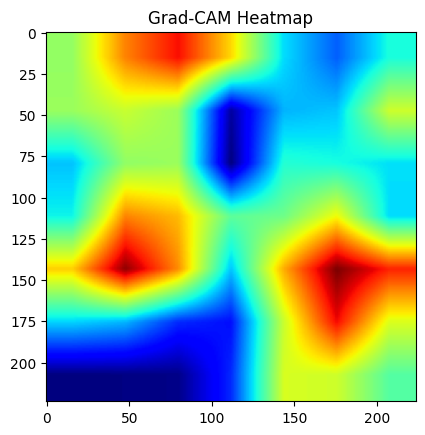

In [42]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

target_layer = model.conv_head

cam = GradCAM(model=model, target_layers=[target_layer])

sample_img, _ = val_ds[0]
input_tensor = sample_img.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

plt.imshow(grayscale_cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.show()

In [8]:
from ultralytics import YOLO

model_yolo = YOLO("yolov8n.pt")

model_yolo.train(
    data="/content/yolo/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    lr0=0.001,
    optimizer="Adam",
    patience=3,
    cache=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=3, perspective=0.0, p

KeyboardInterrupt: 

In [2]:
metrics = model_yolo.val()

print("YOLO Optimized Results")
print("mAP@0.5:", round(metrics.box.map50,3))
print("mAP@0.5:0.95:", round(metrics.box.map,3))

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2025.4±467.9 MB/s, size: 117.1 KB)
val: Scanning /content/yolo/labels/train.cache... 4394 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4394/4394 1.2Git/s 0.0s
train: /content/yolo/images/train/01c2b9fcb0384c84648ed76c736552a8.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/15acee7728e6530dfa2bd01521c7148d.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/305c85dddfdddac905f288a8106ca371.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/57a11dff1b33a1e011eb9ccd9a2f24cc.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/58ab031cf2346b3a7b8fb32fb9ccd1c1.jpg: 1 duplicate labels removed
train: /content/yolo/images/train/613fd7f3a8b48248d4027c90a414ff9a.jpg: 1 duplicate labels removed
train: /content/yolo/images

In [9]:
from ultralytics import YOLO
model_yolo = YOLO("yolov8n.pt")

In [ ]:
results = model_yolo.predict(source="/content/yolo/images/train", save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/4394 /content/yolo/images/train/0005e8e3701dfb1dd93d53e2ff537b6e.jpg: 640x640 1 person, 8.8ms
image 2/4394 /content/yolo/images/train/0007d316f756b3fa0baea2ff514ce945.jpg: 640x640 1 person, 1 bed, 7.6ms
image 3/4394 /content/yolo/images/train/000d68e42b71d3eac10ccc077aba07c1.jpg: 640x640 1 person, 1 cat, 1 bed, 7.5ms
image 4/4394 /content/yolo/images/train/00150343289f317a0ad5629d5b7d9ef9.jpg: 640x640 (no detections), 8.7ms
image 5/4394 /content/

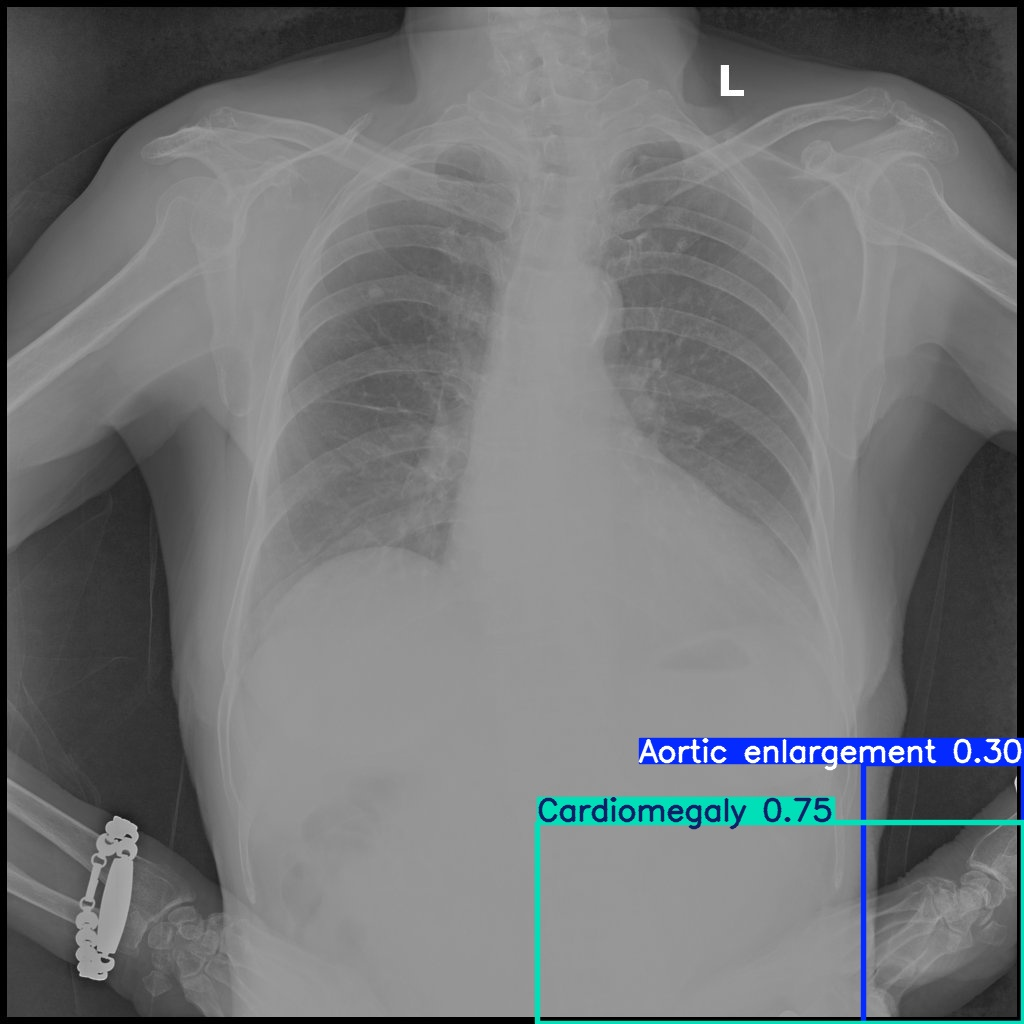

In [2]:
from PIL import Image
from IPython.display import display
import os

pred_path = "/content/runs/detect/predict"

img_file = os.listdir(pred_path)[0]

display(Image.open(f"{pred_path}/{img_file}"))